5-1-1

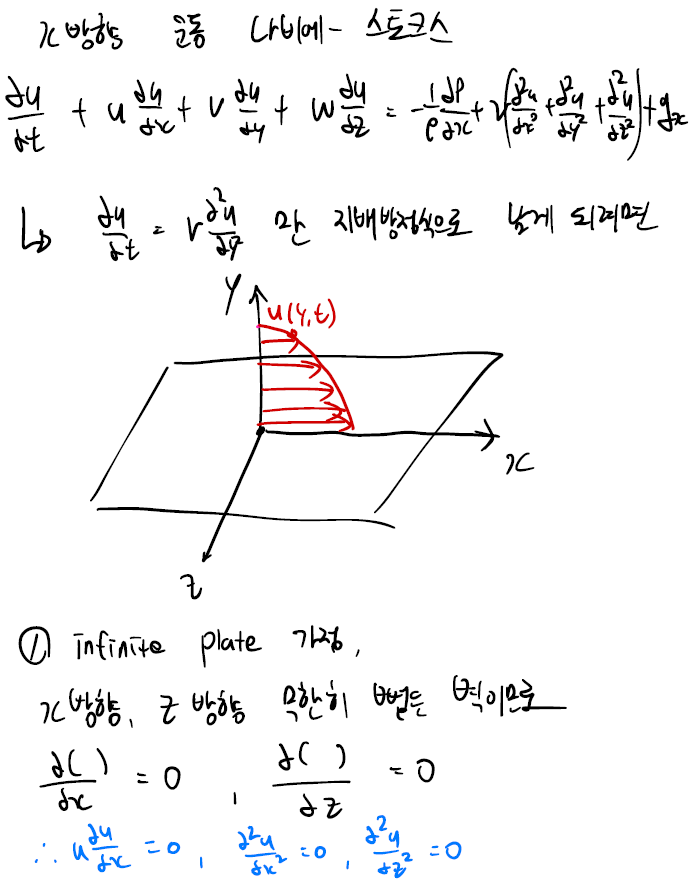
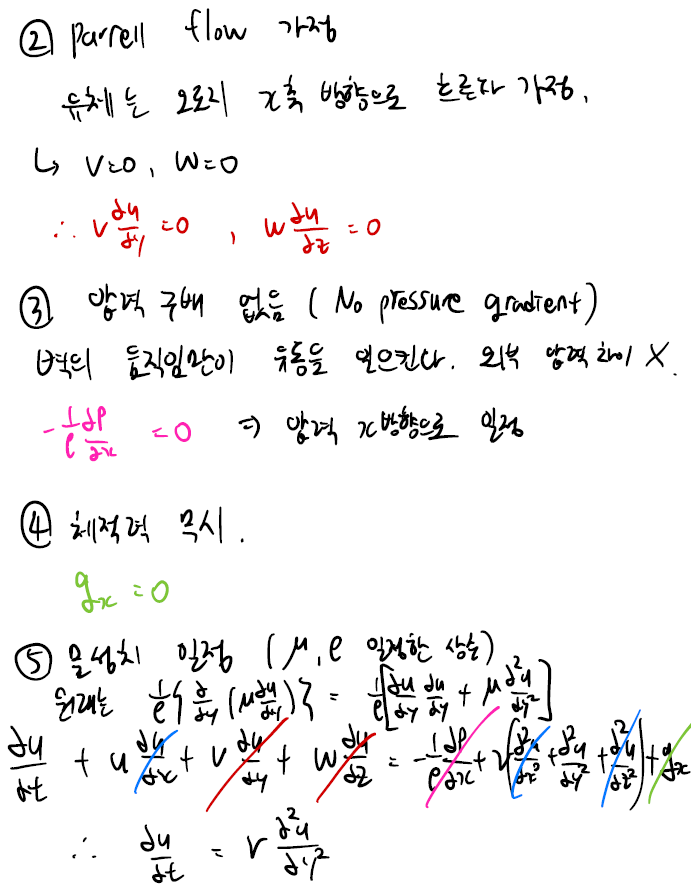

5-1-2

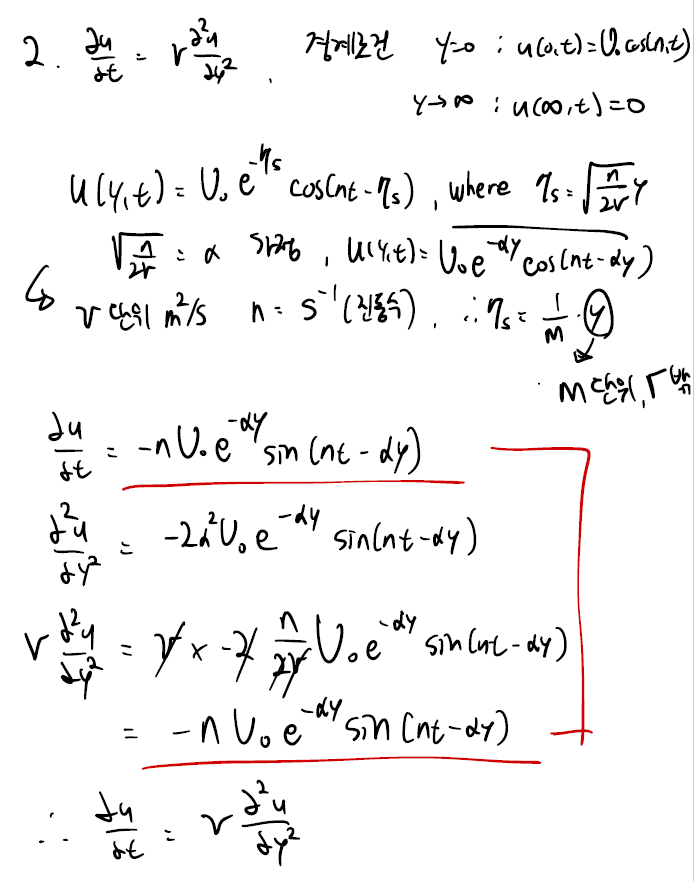

5-2-1

--- Simulation Setup ---
Cycle Period (T): 3.1416s
Time Step (dt):   0.004995s
Steps per Cycle:  629 steps
Stability (r):    0.4995 (Must be <= 0.5)


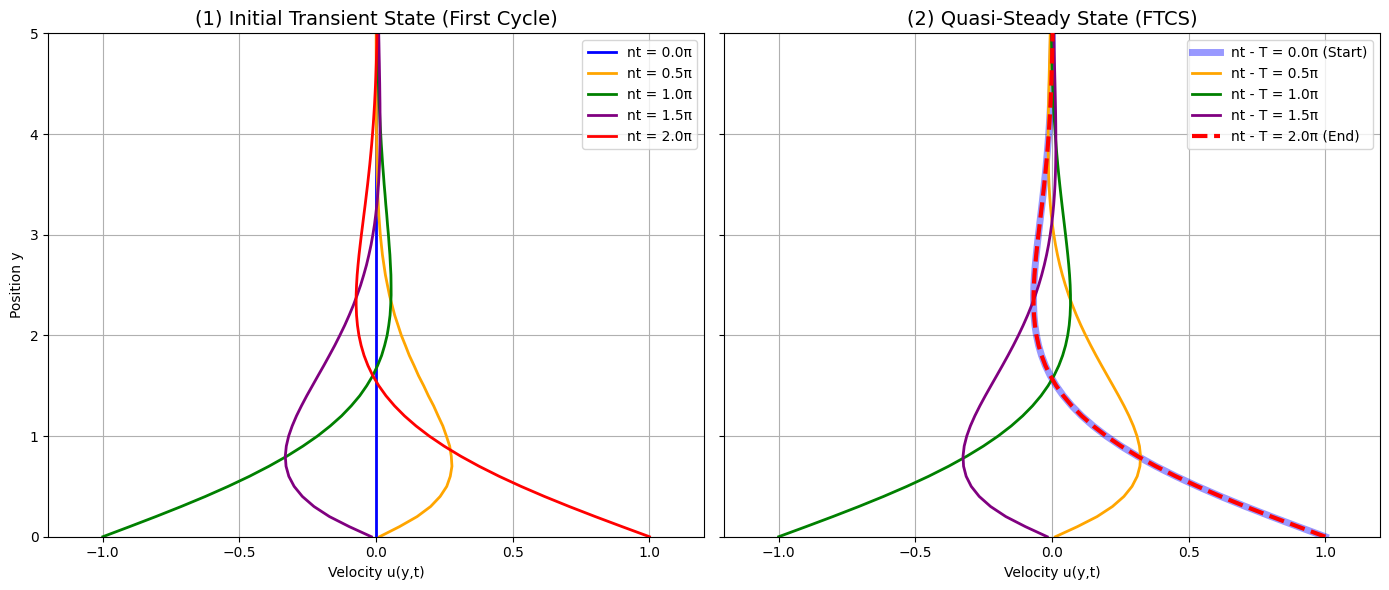

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 문제 조건 설정 (Physical Parameters)
# ==========================================
nu = 1.0        # 동점성계수 (Diffusion coefficient)
n = 2.0         # 각진동수 (Angular frequency)
U0 = 1.0        # 벽의 진동 진폭
L = 10.0        # 벽 사이 거리 (충분히 멀리 설정)
T_period = 2 * np.pi / n  # 진동의 한 주기 (약 3.14초)

# ==========================================
# 2. 공간 격자 생성 (Spatial Grid)
# ==========================================
ny = 101
dy = L / (ny - 1)
y = np.linspace(0, L, ny)

# ==========================================
# 3. [FTCS 핵심 1] 시간 간격(dt) 설정 (Stability)
# ==========================================
# FTCS 방법은 조건부 안정(Conditionally Stable)하므로,
# 확산 수(r)가 0.5보다 작거나 같아야만 계산이 폭발하지 않습니다.
# r = (nu * dt) / dy^2 <= 0.5  -->  dt <= 0.5 * dy^2 / nu
dt_limit = 0.5 * (dy**2) / nu   # 안정성을 보장하는 최대 허용 dt

# 그래프를 깔끔하게 그리기 위해, 한 주기가 정수 개의 스텝으로 딱 떨어지도록 조정
min_steps_per_cycle = int(np.ceil(T_period / dt_limit)) 
N_steps = min_steps_per_cycle   # 한 주기를 구성하는 스텝 수
dt = T_period / N_steps         # 최종 결정된 dt (안정성 조건 만족함)

# 확산 수 (Diffusion Number) r 계산
# 이 r 값이 FTCS 공식의 계수로 들어갑니다.
r = nu * dt / (dy**2)           

print(f"--- Simulation Setup ---")
print(f"Cycle Period (T): {T_period:.4f}s")
print(f"Time Step (dt):   {dt:.6f}s")
print(f"Steps per Cycle:  {N_steps} steps")
print(f"Stability (r):    {r:.4f} (Must be <= 0.5)")

# ==========================================
# 4. 시뮬레이션 함수 (Solver)
# ==========================================
def solve_stokes_synchronized(total_cycles):
    u = np.zeros(ny) # 초기 속도 분포 (t=0일 때 정지 상태 가정)
    profiles = {}    # 그래프 그릴 데이터를 저장할 딕셔너리
    
    # 저장할 시점(타이밍) 계산
    target_indices = [
        0, 
        int(N_steps * 0.25), 
        int(N_steps * 0.50), 
        int(N_steps * 0.75), 
        N_steps
    ]
    
    t = 0.0
    total_steps = total_cycles * N_steps
    
    # 시간 반복문 (Time-marching loop)
    for step in range(total_steps + 1):
        
        # --- 데이터 저장 (Plotting을 위한 부분) ---
        # (이 부분은 계산 로직과는 무관합니다)
        if total_cycles == 1: # (Case 1) 첫 번째 주기인 경우
            if step in target_indices:
                phase = (step / N_steps) * 2 * np.pi
                profiles[phase] = u.copy()
        else: # (Case 2) 마지막 주기인 경우 (정상 상태 확인용)
            start_step_last = (total_cycles - 1) * N_steps
            if step >= start_step_last:
                current_cycle_step = step - start_step_last
                if current_cycle_step in target_indices:
                    phase = (current_cycle_step / N_steps) * 2 * np.pi
                    profiles[phase] = u.copy()

        # ---------------------------------------------------------
        # [FTCS 핵심 2] 메인 계산 로직
        # ---------------------------------------------------------
        
        # 1. 경계 조건 (Boundary Conditions) 업데이트
        # 벽면 (y=0): 코사인 파형으로 진동
        current_phase = (step % N_steps) / N_steps * 2 * np.pi
        u[0] = U0 * np.cos(current_phase)
        
        # 무한 원방 (y=L): 속도 0 (영향 없음)
        u[-1] = 0.0
        
        # 2. 내부 격자점 업데이트 (Finite Difference Update)
        # 식: u_new = u_old + r * (u_left - 2*u_center + u_right)
        if step < total_steps:
            # u[1:-1] : 현재(n) 시점의 내부 점들 (i)
            # u[2:]   : 현재(n) 시점의 오른쪽 이웃 점들 (i+1)
            # u[:-2]  : 현재(n) 시점의 왼쪽 이웃 점들 (i-1)
            # 벡터 연산(Slicing)을 통해 for문 없이 한 번에 계산합니다.
            
            u[1:-1] = u[1:-1] + r * (u[2:] - 2*u[1:-1] + u[:-2])  # <--- 여기가 FTCS 공식!
            
            t += dt

    return profiles

# --- 실행 ---
# 1주기만 돌려서 과도 응답(Transient) 확인
prof_transient = solve_stokes_synchronized(total_cycles=1)
# 10주기 돌려서 정상 상태(Quasi-Steady) 확인
prof_steady = solve_stokes_synchronized(total_cycles=10)


# --- 그래프 그리기 (시각화) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

def get_phase_color(norm_p):
    if abs(norm_p - 0.0) < 0.01: return 'blue'
    if abs(norm_p - 0.5) < 0.01: return 'orange'
    if abs(norm_p - 1.0) < 0.01: return 'green'
    if abs(norm_p - 1.5) < 0.01: return 'purple'
    if abs(norm_p - 2.0) < 0.01: return 'red'
    return 'black'

# 그래프 1
ax = axes[0]
for phase, data in sorted(prof_transient.items()):
    norm_phase = phase / np.pi
    color = get_phase_color(norm_phase)
    label = f"nt = {norm_phase:.1f}π"
    ax.plot(data, y, label=label, linewidth=2, color=color)

ax.set_title("(1) Initial Transient State (First Cycle)", fontsize=14)
ax.set_xlabel("Velocity u(y,t)")
ax.set_ylabel("Position y")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(0, 5.0) 
ax.grid(True)
ax.legend(loc='upper right')

# 그래프 2
ax = axes[1]
for phase, data in sorted(prof_steady.items()):
    norm_phase = phase / np.pi
    color = get_phase_color(norm_phase)
    if abs(norm_phase - 2.0) < 0.01: 
        label = "nt - T = 2.0π (End)"
        ax.plot(data, y, label=label, linewidth=3, linestyle='--', color=color, zorder=10)
    elif abs(norm_phase) < 0.01:
        label = "nt - T = 0.0π (Start)"
        ax.plot(data, y, label=label, linewidth=5, color=color, alpha=0.4)
    else:
        label = f"nt - T = {norm_phase:.1f}π"
        ax.plot(data, y, label=label, linewidth=2, color=color)

ax.set_title("(2) Quasi-Steady State (FTCS)", fontsize=14) 
ax.set_xlabel("Velocity u(y,t)")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(0, 5.0) 
ax.grid(True)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

5-2-2

--- Setup ---
Exact dt: 0.009973
Steps per Cycle: 315
Parameter r: 0.49867


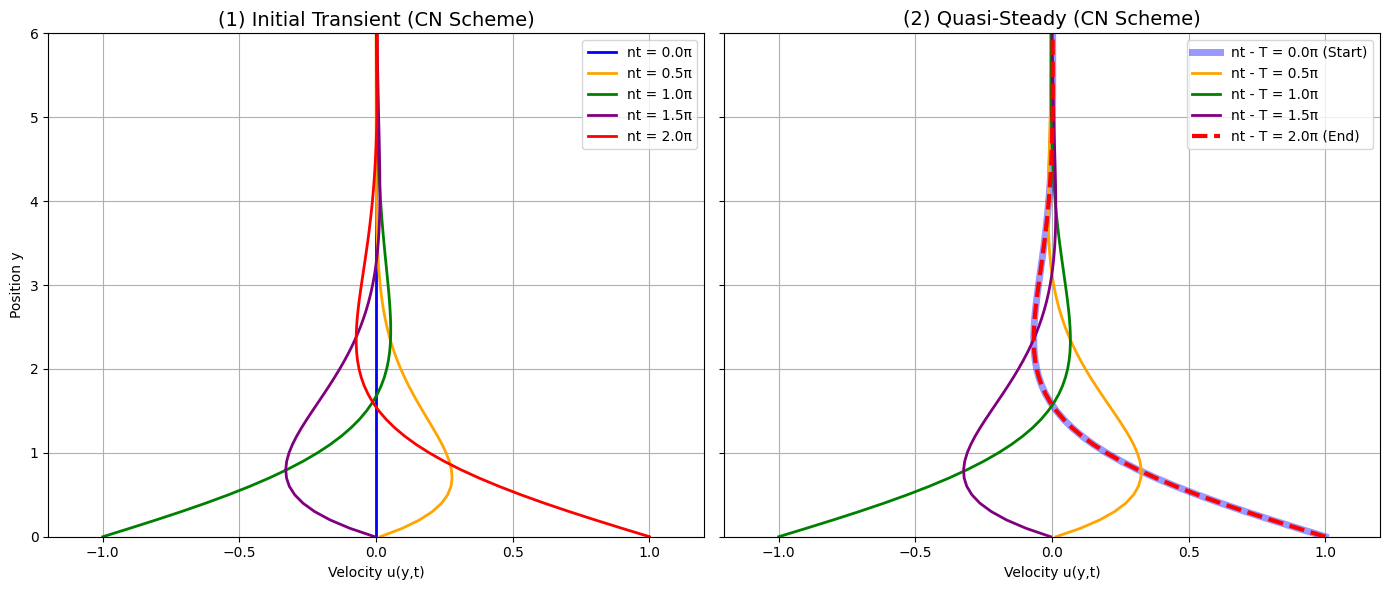

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# 1. 문제 조건 설정
nu = 1.0        # 동점성계수
n = 2.0         # 진동수
U0 = 1.0        # 진폭
L = 10.0        # 벽 사이 거리
T_period = 2 * np.pi / n

# 2. 격자 생성
ny = 101
dy = L / (ny - 1)
y = np.linspace(0, L, ny)

# =========================================================
# [CN 핵심 1] 확산 수(r) 계산 (The Parameter)
# =========================================================
target_dt = 0.01
N_steps = int(np.ceil(T_period / target_dt))
dt = T_period / N_steps
# ---------------------------------------------------------
# 중요: 분모에 2가 들어갑니다! (2 * dy**2)
# 이유: CN은 현재(n)와 미래(n+1)의 기울기를 '절반씩(1/2)' 섞어서 사용하기 때문입니다.
# ---------------------------------------------------------
r = (nu * dt) / (2 * dy**2)  

print(f"--- Setup ---")
print(f"Exact dt: {dt:.6f}")
print(f"Steps per Cycle: {N_steps}")
print(f"Parameter r: {r:.5f}")

# =========================================================
# [CN 핵심 2] 좌변 행렬 A 생성 (Implicit Part / LHS)
# =========================================================
# 식: -r*u_{i-1}^{n+1} + (1+2r)*u_{i}^{n+1} - r*u_{i+1}^{n+1} = ...
# 이 식의 계수들을 행렬로 만듭니다. (미래의 값들이라 우리가 구해야 할 미지수들)
# ---------------------------------------------------------
N_interior = ny - 2
main_diag = (1 + 2*r) * np.ones(N_interior) # 대각 성분 (나 자신)
off_diag = -r * np.ones(N_interior - 1)     # 대각 옆 성분 (이웃들)

# 삼중 대각 행렬(Tridiagonal Matrix) 생성
A = diags([off_diag, main_diag, off_diag], [-1, 0, 1], format='csr')

# 5. 시뮬레이션 함수
def solve_crank_nicolson_synced(total_cycles):
    u = np.zeros(ny)
    profiles = {}
    
    target_indices = [
        0, 
        int(N_steps*0.25), 
        int(N_steps*0.5), 
        int(N_steps*0.75), 
        N_steps
    ]
    
    t = 0.0
    total_steps = total_cycles * N_steps
    
    for step in range(total_steps + 1):
        
        # --- 1. 저장 로직 (생략) ---
        if total_cycles == 1:
            if step in target_indices:
                phase = (step / N_steps) * 2 * np.pi
                profiles[phase] = u.copy()
        else:
            start_step = (total_cycles - 1) * N_steps
            if step >= start_step:
                curr_step = step - start_step
                if curr_step in target_indices:
                    phase = (curr_step / N_steps) * 2 * np.pi
                    profiles[phase] = u.copy()
        
        # =========================================================
        # [CN 핵심 3] 우변 벡터 b 생성 및 풀이 (Explicit Part & Solver)
        # =========================================================
        if step < total_steps:
            t_next = t + dt
            
            # 경계 조건 (Boundary Values)
            u_bottom_next = U0 * np.cos(n * t_next) # 미래의 바닥 값 (Boundary)
            u_top = 0.0                             # 미래의 천장 값
            
            # 1) 우변 벡터 b 구성 (Explicit Part)
            # 식: r*u_{i-1}^n + (1-2r)*u_{i}^n + r*u_{i+1}^n
            # 현재 알고 있는 값(n)들을 이용해 우변 값을 계산
            u_interior = u[1:-1]
            b = r * u[:-2] + (1 - 2*r) * u_interior + r * u[2:]
            
            # 2) 경계조건 이항 (Handling Boundary Conditions)
            # 행렬 식에서 경계값(상수)을 우변으로 넘겨서 b에 더해줍니다.
            b[0] += r * u_bottom_next  # 바닥 쪽 경계값 반영
            b[-1] += r * u_top         # 천장 쪽 경계값 반영
            
            # 3) 연립방정식 풀이 (Linear Solver)
            # A * x = b  ->  x = A_inverse * b
            # 여기서 x가 바로 우리가 구하고 싶은 미래의 내부 점들(u_interior_next)입니다.
            u_interior_next = spsolve(A, b)
            
            # 4) 결과 업데이트
            u[0] = u_bottom_next        # 바닥 업데이트
            u[1:-1] = u_interior_next   # 내부 업데이트 (방금 푼 것)
            u[-1] = u_top               # 천장 업데이트
            
            t = t_next

    return profiles

# --- 실행 ---
profiles_transient = solve_crank_nicolson_synced(total_cycles=1)
profiles_steady = solve_crank_nicolson_synced(total_cycles=10) # 충분히 길게

# --- 그래프 그리기 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# [색상 지정 함수]
def get_phase_color(norm_p):
    if abs(norm_p - 0.0) < 0.01: return 'blue'      # 0.0pi
    if abs(norm_p - 0.5) < 0.01: return 'orange'    # 0.5pi
    if abs(norm_p - 1.0) < 0.01: return 'green'     # 1.0pi
    if abs(norm_p - 1.5) < 0.01: return 'purple'    # 1.5pi
    if abs(norm_p - 2.0) < 0.01: return 'red'       # 2.0pi
    return 'black'

# 그래프 1: Transient
ax = axes[0]
for phase, data in sorted(profiles_transient.items()):
    norm_phase = phase / np.pi
    color = get_phase_color(norm_phase)
    
    label = f"nt = {norm_phase:.1f}π"
    ax.plot(data, y, label=label, linewidth=2, color=color)
    
ax.set_title("(1) Initial Transient (CN Scheme)", fontsize=14)
ax.set_xlabel("Velocity u(y,t)")
ax.set_ylabel("Position y")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(0, 5.0) 
ax.legend(loc='upper right')
ax.grid(True)

# 그래프 2: Quasi-Steady
ax = axes[1]
for phase, data in sorted(profiles_steady.items()):
    norm_phase = phase / np.pi
    color = get_phase_color(norm_phase)
    
    # 2.0pi (빨강 점선)
    if abs(norm_phase - 2.0) < 0.01:
        label = "nt - T = 2.0π (End)"
        ax.plot(data, y, label=label, linewidth=3, linestyle='--', color=color, zorder=10)
    
    # 0.0pi (파랑 실선 - 굵고 투명하게)
    elif abs(norm_phase) < 0.01:
        label = "nt - T = 0.0π (Start)"
        ax.plot(data, y, label=label, linewidth=5, color=color, alpha=0.4)
        
    else:
        label = f"nt - T = {norm_phase:.1f}π"
        ax.plot(data, y, label=label, linewidth=2, color=color)

ax.set_title("(2) Quasi-Steady (CN Scheme)", fontsize=14)
ax.set_xlabel("Velocity u(y,t)")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(0, 6.0) 
ax.legend(loc='upper right')
ax.grid(True)

plt.tight_layout()
plt.show()

5-2-3

Generating Reference Solution (Conceptually Exact on this Grid)...
-------------------------------------------------------
Method | dt           | L2 Error (vs Ref) 
-------------------------------------------------------
FTCS   | 0.001125   | 2.340142e-04
FTCS   | 0.000563   | 1.172693e-04
FTCS   | 0.000281   | 5.892154e-05
FTCS   | 0.000141   | 2.976463e-05
CN     | 0.100264   | 9.385050e-04
CN     | 0.050132   | 2.353093e-04
CN     | 0.024999   | 5.952072e-05
CN     | 0.012500   | 1.590805e-05


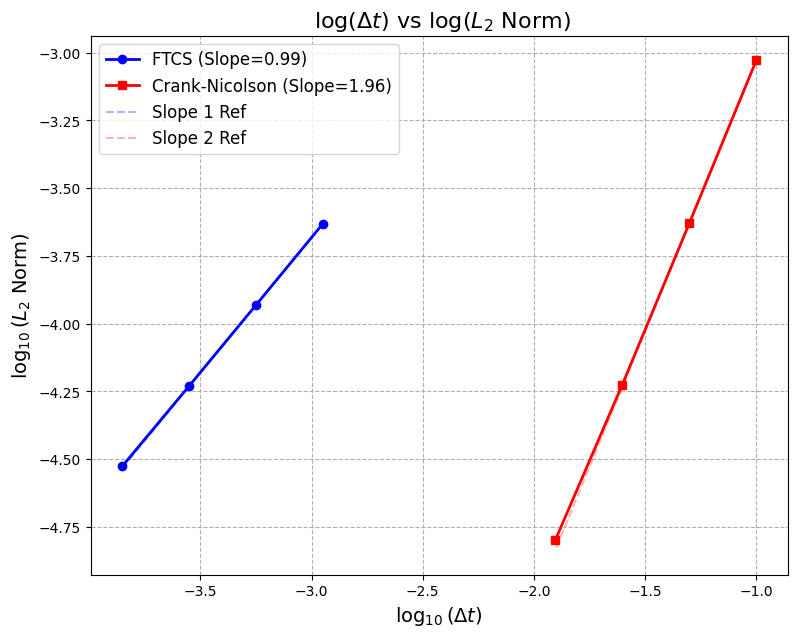

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# 1. 설정
nu = 1.0
n = 2.0
U0 = 1.0
L = 10.0
total_cycles = 3
T_final = total_cycles * (2 * np.pi / n)

# 격자 설정
ny = 201 
dy = L / (ny - 1)
y = np.linspace(0, L, ny)

# 초기 조건용 Exact Solution 함수
def get_exact_ic(y):
    eta_s = np.sqrt(n / (2 * nu)) * y
    return U0 * np.exp(-eta_s) * np.cos(-eta_s) # t=0

# --- 통합 Solver (FTCS & CN) ---
def run_simulation(method, dt, steps):
    if method == 'FTCS':
        r = nu * dt / (dy**2)
        if r > 0.500001: return None 
    else: # CN
        r = (nu * dt) / (2 * dy**2)

    # 초기 조건: Hot Start
    u = get_exact_ic(y)
    t = 0.0
    
    # CN 행렬 
    if method == 'CN':
        N_int = ny - 2
        main_diag = (1 + 2*r) * np.ones(N_int)
        off_diag = -r * np.ones(N_int - 1)
        A = diags([off_diag, main_diag, off_diag], [-1, 0, 1], format='csr')

    for _ in range(steps):
        t_next = t + dt
        u_bot_next = U0 * np.cos(n * t_next)
        u_top = 0.0

        if method == 'FTCS':
            u_current_bc = U0 * np.cos(n * t)
            u[0] = u_current_bc
            u[-1] = u_top
            u[1:-1] = u[1:-1] + r * (u[2:] - 2*u[1:-1] + u[:-2])
            
        elif method == 'CN':
            u_int = u[1:-1]
            b = r * u[:-2] + (1 - 2*r) * u_int + r * u[2:]
            b[0] += r * u_bot_next
            b[-1] += r * u_top
            u_int_next = spsolve(A, b)
            u[0] = u_bot_next
            u[1:-1] = u_int_next
            u[-1] = u_top
            
        t = t_next
        
    return u

# --- 2. 기준해 (Reference Solution) 생성 ---
print("Generating Reference Solution (Conceptually Exact on this Grid)...")

# Reference용 dt는 매우 작게 (예: 1e-5)
dt_ref = 1e-5
steps_ref = int(np.round(T_final / dt_ref))
# 정확도가 높은 CN으로 기준해 생성
u_ref = run_simulation('CN', dt_ref, steps_ref) 

# --- 3. 수렴성 테스트 ---

# (A) FTCS 테스트: 안정성 범위 내의 dt들
limit_dt = 0.5 * (dy**2) / nu
ftcs_dts = [limit_dt * 0.9, limit_dt * 0.45, limit_dt * 0.225, limit_dt * 0.1125]

# (B) CN 테스트: 적당히 큰 dt들 
cn_dts = [0.1, 0.05, 0.025, 0.0125]

ftcs_errors = []
cn_errors = []
ftcs_valid_dts = []
cn_valid_dts = []

print("-" * 55)
print(f"{'Method':<6} | {'dt':<12} | {'L2 Error (vs Ref)':<18}")
print("-" * 55)

# FTCS Loop
for dt in ftcs_dts:
    steps = int(np.round(T_final / dt))
    dt_synced = T_final / steps
    u = run_simulation('FTCS', dt_synced, steps)
    if u is not None:
        # Reference Solution과 비교 (공간 오차 상쇄!)
        err = np.sqrt(np.sum((u - u_ref)**2) * dy)
        ftcs_errors.append(err)
        ftcs_valid_dts.append(dt_synced)
        print(f"{'FTCS':<6} | {dt_synced:.6f}   | {err:.6e}")

# CN Loop
for dt in cn_dts:
    steps = int(np.round(T_final / dt))
    dt_synced = T_final / steps
    u = run_simulation('CN', dt_synced, steps)
    # Reference Solution과 비교
    err = np.sqrt(np.sum((u - u_ref)**2) * dy)
    cn_errors.append(err)
    cn_valid_dts.append(dt_synced)
    print(f"{'CN':<6} | {dt_synced:.6f}   | {err:.6e}")


# --- 4. 결과 Plotting (Literal log vs log) ---
ftcs_valid_dts = np.array(ftcs_valid_dts)
ftcs_errors = np.array(ftcs_errors)
cn_valid_dts = np.array(cn_valid_dts)
cn_errors = np.array(cn_errors)

# 기울기(Slope) 계산 
slope_ftcs, _ = np.polyfit(np.log(ftcs_valid_dts), np.log(ftcs_errors), 1)
slope_cn, _ = np.polyfit(np.log(cn_valid_dts), np.log(cn_errors), 1)

plt.figure(figsize=(9, 7))


# x축: log10(dt), y축: log10(L2norm)
plt.plot(np.log10(ftcs_valid_dts), np.log10(ftcs_errors), 'o-', label=f'FTCS (Slope={slope_ftcs:.2f})', color='blue', linewidth=2)
plt.plot(np.log10(cn_valid_dts), np.log10(cn_errors), 's-', label=f'Crank-Nicolson (Slope={slope_cn:.2f})', color='red', linewidth=2)


# FTCS Ref (Slope 1) -> log(y) = 1 * log(x) + C
x_log_ftcs = np.log10(ftcs_valid_dts)
y_ref_ftcs = 1.0 * (x_log_ftcs - x_log_ftcs[0]) + np.log10(ftcs_errors[0])
plt.plot(x_log_ftcs, y_ref_ftcs, 'b--', alpha=0.3, label='Slope 1 Ref')

# CN Ref (Slope 2) -> log(y) = 2 * log(x) + C
x_log_cn = np.log10(cn_valid_dts)
y_ref_cn = 2.0 * (x_log_cn - x_log_cn[0]) + np.log10(cn_errors[0])
plt.plot(x_log_cn, y_ref_cn, 'r--', alpha=0.3, label='Slope 2 Ref')


plt.xlabel(r'$\log_{10}(\Delta t)$', fontsize=14)
plt.ylabel(r'$\log_{10}(L_2\ \mathrm{Norm})$', fontsize=14)
plt.title(r' $\log(\Delta t)$ vs $\log(L_2\ \mathrm{Norm})$', fontsize=16)

plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--")
plt.show()

5-2-4

--- Setup ---
Exact dt: 0.009973
Steps per Cycle: 315
Parameter r: 12.46664


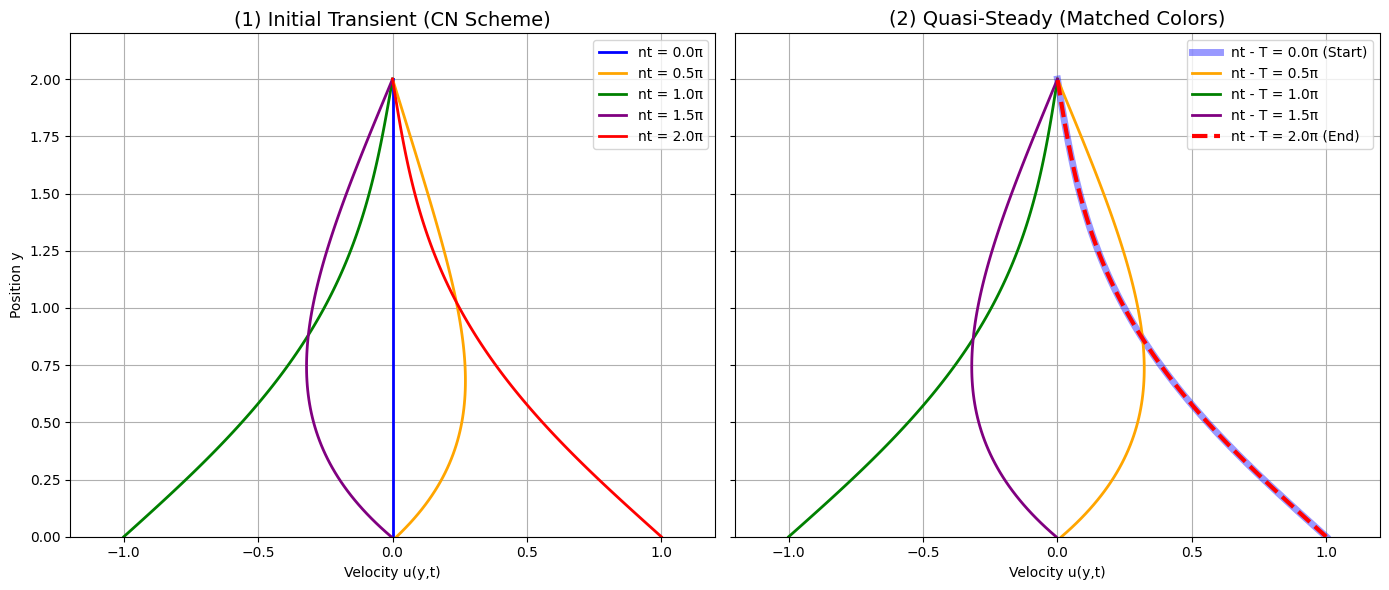

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# 1. 문제 조건 설정
nu = 1.0        # 동점성계수
n = 2.0         # 진동수
U0 = 1.0        # 진폭
L = 2.0        # 벽 사이 거리
T_period = 2 * np.pi / n

# 2. 격자 생성
ny = 101
dy = L / (ny - 1)
y = np.linspace(0, L, ny)

# 3. [핵심] Time Step 동기화 (Crank-Nicolson용)
target_dt = 0.01  # 목표로 하는 대략적인 dt
N_steps = int(np.ceil(T_period / target_dt)) # 정수 스텝으로 분할
dt = T_period / N_steps  # 정확한 dt
r = (nu * dt) / (2 * dy**2)

print(f"--- Setup ---")
print(f"Exact dt: {dt:.6f}")
print(f"Steps per Cycle: {N_steps}")
print(f"Parameter r: {r:.5f}")

# 4. 행렬 A 생성
N_interior = ny - 2
main_diag = (1 + 2*r) * np.ones(N_interior)
off_diag = -r * np.ones(N_interior - 1)
A = diags([off_diag, main_diag, off_diag], [-1, 0, 1], format='csr')

# 5. 시뮬레이션 함수
def solve_crank_nicolson_synced(total_cycles):
    u = np.zeros(ny)
    profiles = {}
    
    # 저장할 목표 스텝 (정수 인덱스)
    target_indices = [
        0, 
        int(N_steps*0.25), 
        int(N_steps*0.5), 
        int(N_steps*0.75), 
        N_steps
    ]
    
    t = 0.0
    total_steps = total_cycles * N_steps
    
    # range(total_steps + 1) -> 마지막 점 포함
    for step in range(total_steps + 1):
        
        # --- 1. 저장 로직 (계산 전 수행) ---
        if total_cycles == 1: # Transient
            if step in target_indices:
                phase = (step / N_steps) * 2 * np.pi
                profiles[phase] = u.copy()
                
        else: # Quasi-Steady
            start_step = (total_cycles - 1) * N_steps
            if step >= start_step:
                curr_step = step - start_step
                if curr_step in target_indices:
                    phase = (curr_step / N_steps) * 2 * np.pi
                    profiles[phase] = u.copy()
        
        # --- 2. 다음 스텝 계산 ---
        if step < total_steps:
            t_next = t + dt
            
            # 경계 조건
            u_bottom_next = U0 * np.cos(n * t_next)
            u_top = 0.0
            
            # RHS 벡터 b 구성
            u_interior = u[1:-1]
            b = r * u[:-2] + (1 - 2*r) * u_interior + r * u[2:]
            
            # 경계조건 이항
            b[0] += r * u_bottom_next
            b[-1] += r * u_top
            
            # 풀이 및 업데이트
            u_interior_next = spsolve(A, b)
            
            u[0] = u_bottom_next
            u[1:-1] = u_interior_next
            u[-1] = u_top
            
            t = t_next

    return profiles

# --- 실행 ---
profiles_transient = solve_crank_nicolson_synced(total_cycles=1)
profiles_steady = solve_crank_nicolson_synced(total_cycles=10) # 충분히 길게

# --- 그래프 그리기 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# [색상 지정 함수]
def get_phase_color(norm_p):
    if abs(norm_p - 0.0) < 0.01: return 'blue'      # 0.0pi
    if abs(norm_p - 0.5) < 0.01: return 'orange'    # 0.5pi
    if abs(norm_p - 1.0) < 0.01: return 'green'     # 1.0pi
    if abs(norm_p - 1.5) < 0.01: return 'purple'    # 1.5pi
    if abs(norm_p - 2.0) < 0.01: return 'red'       # 2.0pi
    return 'black'

# 그래프 1: Transient
ax = axes[0]
for phase, data in sorted(profiles_transient.items()):
    norm_phase = phase / np.pi
    color = get_phase_color(norm_phase)
    
    label = f"nt = {norm_phase:.1f}π"
    ax.plot(data, y, label=label, linewidth=2, color=color)
    
ax.set_title("(1) Initial Transient (CN Scheme)", fontsize=14)
ax.set_xlabel("Velocity u(y,t)")
ax.set_ylabel("Position y")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(0, 5.0) 
ax.legend(loc='upper right')
ax.grid(True)

# 그래프 2: Quasi-Steady
ax = axes[1]
for phase, data in sorted(profiles_steady.items()):
    norm_phase = phase / np.pi
    color = get_phase_color(norm_phase)
    
    # 2.0pi (빨강 점선)
    if abs(norm_phase - 2.0) < 0.01:
        label = "nt - T = 2.0π (End)"
        ax.plot(data, y, label=label, linewidth=3, linestyle='--', color=color, zorder=10)
    
    # 0.0pi (파랑 실선 - 굵고 투명하게)
    elif abs(norm_phase) < 0.01:
        label = "nt - T = 0.0π (Start)"
        ax.plot(data, y, label=label, linewidth=5, color=color, alpha=0.4)
        
    else:
        label = f"nt - T = {norm_phase:.1f}π"
        ax.plot(data, y, label=label, linewidth=2, color=color)

ax.set_title("(2) Quasi-Steady (Matched Colors)", fontsize=14)
ax.set_xlabel("Velocity u(y,t)")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(0, 2.2) 
ax.legend(loc='upper right')
ax.grid(True)

plt.tight_layout()
plt.show()